# COARE 3.5 Diurnal Warm Layer — Python Port with Witte et al. (2024) Solar Absorption

**DWL reference:** Fairall et al. (1996), updated COARE 3.5. Code ported from  
[NOAA-PSL/COARE-algorithm `coare35vnWarm.m`](https://github.com/NOAA-PSL/COARE-algorithm)

**Solar absorption modification:** Witte, Subramaniam & Zappa (2024), JGR Oceans.  
`doi:10.1029/2024JC021049`

---

## DWL physics summary

The Diurnal Warm Layer (DWL) model tracks two prognostic variables:
- **`dt_wrm`** — temperature excess across the warm layer (°C)
- **`tk_pwp`** — warm layer thickness (m)

Physics is a Pollard–Rhines–Thompson (PRT) bulk mixed-layer model:

```
tk_pwp  = ctd1 × τ_acc / √Q_acc        (depth: momentum vs. buoyancy)
dt_wrm  = ctd2 × Q_acc^1.5 / τ_acc     (temp: heat content)

τ_acc   = ∫ τ_wind dt     (accumulated momentum, Pa·s)
Q_acc   = ∫ q_pwp  dt     (accumulated heat, J/m²)
q_pwp   = fxp × Rns − q_cool           (net heat into warm layer)
```

**`fxp`** — fraction of net solar (`Rns`) absorbed in [0, `tk_pwp`] — is the single line  
Witte et al. replace with a chlorophyll-dependent bio-optical parameterization.

| Absorption scheme | `fxp` formula |
|---|---|
| Soloviev 1982 (COARE default) | 3-band exponential, fixed e-folding depths |
| Witte et al. 2024 | 5-band, Kd = f(Chl) via Morel et al. 2007 |

**Forcing needed:** Solar (↓SW), IR (↓LW), wind speed, sensible heat flux,  
latent heat flux, SST — all hourly. Sourced from ERA5 at the DBASIS position.

In [22]:
# -------------------------------------------------------
# COARE 3.5 DWL — Python port + Witte et al. (2024) solar absorption
# -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('figs', exist_ok=True)

# -------------------------------------------------------------------
# Solar absorption: Witte et al. (2024) five-band parameterization
# Returns Ed(z) / [SW*(1-α)] — fractional irradiance profile
# -------------------------------------------------------------------
def _final_param_scale(Chl, z):
    """Witte et al. (2024) irradiance fraction at depth z (m), given Chl (mg/m³)."""
    Auv, Ab, Ay, Ar, Air = 0.06, 0.17, 0.14, 0.14, 0.49
    Kd_UV = 0.0218 + 0.1758 * Chl**0.6541
    Kd_B  = 0.0119 + 0.1048 * Chl**0.6330
    Kd_Y  = 0.0665 + 0.0582 * Chl**0.5342
    Kd_R  = 0.3608 + 0.0585 * Chl**0.4723
    C1, C2, C3, C4 = 1.87, 0.47, 0.66, 30
    return (Auv * np.exp(-Kd_UV * z)
          + Ab  * np.exp(-Kd_B  * z)
          + Ay  * np.exp(-Kd_Y  * z)
          + Ar  * np.exp(-Kd_R  * z)
          + Air * np.exp(-C1 * z) * (1 - C2 * np.arctan(C3 + C4 * z)))


# -------------------------------------------------------------------
# fxp: fraction of Rns absorbed in the warm layer [0, h]
# -------------------------------------------------------------------
def compute_fxp(h, Chl=None):
    """
    Fraction of net solar (Rns) absorbed within warm layer depth h (m).
    fxp=0 → no heating (h→0); fxp=1 → all absorbed (h→∞).

    Chl=None   → Soloviev 1982 (COARE 3.5 default, kept for reference)
    Chl='PS77' → Paulson & Simpson (1977), two-band, no Chl (Navy HYCOM)
    Chl=float  → Witte et al. 2024 five-band bio-optical
    """
    if h < 1e-3:
        return 0.0
    if Chl is None:
        # Soloviev 1982 — three exponential bands (COARE 3.5 inline formula)
        return 1.0 - (0.28 * 0.014  * (1 - np.exp(-h / 0.014))
                    + 0.27 * 0.357  * (1 - np.exp(-h / 0.357))
                    + 0.45 * 12.82  * (1 - np.exp(-h / 12.82))) / h
    elif Chl == 'PS77':
        # Paulson & Simpson (1977) — Jerlov Type I, two-band, no Chl
        # Used in Navy operational HYCOM (Wallcraft et al. 2009)
        # fxp = 1 - [fraction remaining at depth h]
        return 1.0 - (0.58 * np.exp(-2.86 * h) + 0.42 * np.exp(-0.043 * h))
    else:
        # Witte et al. 2024 — fraction absorbed = [Ed(0) - Ed(h)] / Ed(0)
        Ed0 = _final_param_scale(Chl, 0.0)
        Edh = _final_param_scale(Chl, h)
        return max(0.0, (Ed0 - Edh) / Ed0) if Ed0 > 0 else 0.0


# -------------------------------------------------------------------
# DWL time-stepping model
# Port of coare35vnWarm.m warm-layer physics block
# -------------------------------------------------------------------
def dwl_run(time_utc, Solar, IR, wspd, hs, hl, Tsea, lon,
            Chl=None, ts_depth=1.0):
    """
    Run the COARE 3.5 Diurnal Warm Layer (DWL) model over a time series.

    The model is a Pollard-Rhines-Thompson (PRT) bulk mixed-layer scheme.
    It tracks the temperature excess (dt_wrm) and thickness (tk_pwp) of
    the warm layer that forms each day under calm, sunny conditions.

    Parameters
    ----------
    time_utc  : pd.DatetimeIndex — UTC timestamps, hourly
    Solar     : downwelling shortwave irradiance (W/m²), positive downward
    IR        : downwelling longwave irradiance (W/m²), positive downward
    wspd      : wind speed at 10 m (m/s)
    hs        : surface sensible heat flux (W/m²), ERA5 sign: positive = into ocean
    hl        : surface latent heat flux (W/m²), ERA5 sign: positive = into ocean
    Tsea      : bulk sea surface temperature (°C)
    lon       : longitude (°E), used to convert UTC to local solar time
    Chl       : solar absorption scheme / chlorophyll concentration
                  None   → Soloviev 1982 (COARE 3.5 default)
                  'PS77' → Paulson & Simpson (1977) / Navy HYCOM
                  float  → Witte et al. 2024, five-band bio-optical at that Chl (mg/m³)
                  array  → Witte et al. 2024 with time-varying chlorophyll
    ts_depth  : depth of the SST sensor (m), default 1.0 m

    Returns
    -------
    pd.DataFrame with columns:
        dt_wrm — warm layer temperature anomaly (°C)
        tk_pwp — warm layer thickness (m)
        dsea   — SST correction at ts_depth (°C)
    """
    n  = len(time_utc)
    dt = (time_utc[1] - time_utc[0]).total_seconds() if n > 1 else 3600.0

    rich    = 0.65
    max_pwp = 19.0
    sigma   = 5.67e-8
    rho_a   = 1.2

    qcol_ac = 0.0
    tau_ac  = 0.0
    dtw     = 0.0
    h       = max_pwp
    jamset  = 0
    prev_lsh = 0.0

    out_dtwrm = np.zeros(n)
    out_tkpwp = np.full(n, max_pwp)
    out_dsea  = np.zeros(n)

    # Scalar Chl: None, 'PS77', or a float — all treated as scalar
    if Chl is None or isinstance(Chl, str) or np.ndim(Chl) == 0:
        Chl_scalar   = Chl
        Chl_is_array = False
        Chl_arr      = None
    else:
        Chl_is_array = True
        Chl_arr      = Chl

    for i in range(n):
        t   = time_utc[i]
        lsh = (t.hour + t.minute / 60.0 + lon / 15.0) % 24.0

        if prev_lsh > 20.0 and lsh < 4.0:
            qcol_ac = 0.0
            tau_ac  = 0.0
            dtw     = 0.0
            h       = max_pwp
            jamset  = 0
        prev_lsh = lsh

        out_dtwrm[i] = dtw
        out_tkpwp[i] = h

        if lsh < 6.0:
            continue

        Chl_i = Chl_arr[i] if Chl_is_array else Chl_scalar

        Ts   = float(Tsea[i])
        Al   = 2.1e-5 * (Ts + 3.2)**0.79
        g    = 9.8
        cpw  = 4000.0
        rhow = 1022.0

        ctd1 = np.sqrt(2 * rich * cpw / (Al * g * rhow))
        ctd2 = np.sqrt(2 * Al * g / (rich * rhow)) / cpw**1.5

        Rns    = 0.945 * max(0.0, float(Solar[i]))
        Rnl    = 0.97 * (sigma * (Ts + 273.15)**4 - float(IR[i]))
        qr_out = Rnl - float(hs[i]) - float(hl[i])

        U      = max(0.5, float(wspd[i]))
        Cd     = 1.1e-3 + 4e-5 * U
        tau    = rho_a * Cd * U**2
        tau_ac += max(tau, 0.002) * dt

        for _ in range(5):
            fxp   = compute_fxp(max(h, 0.01), Chl_i)
            q_pwp = fxp * Rns - qr_out
            Q_try = qcol_ac + q_pwp * dt
            if Q_try > 0 and tau_ac > 0:
                h = min(max_pwp, ctd1 * tau_ac / np.sqrt(Q_try))
            else:
                h = max_pwp

        if jamset == 0 and (fxp * Rns - qr_out) > 50.0:
            jamset = 1
        if jamset == 0:
            continue

        qcol_ac = max(0.0, qcol_ac + q_pwp * dt)
        dtw = ctd2 * qcol_ac**1.5 / tau_ac if (tau_ac > 0 and qcol_ac > 0) else 0.0

        out_dtwrm[i] = dtw
        out_tkpwp[i] = h

        if h < ts_depth:
            dsea = 0.0
        else:
            dsea = dtw * ts_depth / h
        out_dsea[i] = dsea

    return pd.DataFrame(
        {'dt_wrm': out_dtwrm, 'tk_pwp': out_tkpwp, 'dsea': out_dsea},
        index=time_utc
    )


print('DWL functions loaded: compute_fxp, dwl_run')

DWL functions loaded: compute_fxp, dwl_run


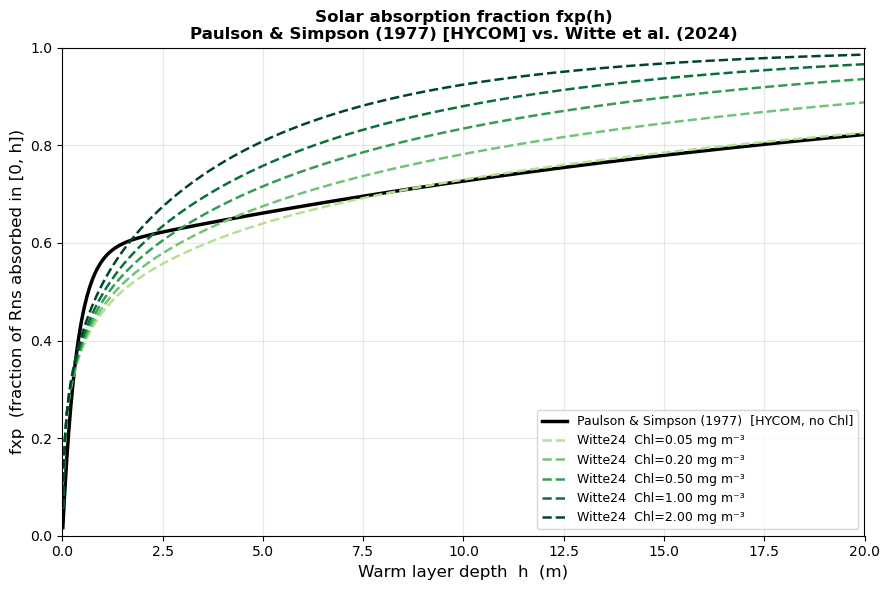

Saved figs/DWL_fxp_curves.png


In [23]:
# -------------------------------------------------------
# Figure 1: fxp(h) curves — show the key difference between
# PS77 (HYCOM baseline) and Witte24 at different Chl concentrations
# -------------------------------------------------------
h_arr = np.linspace(0.01, 20, 400)

fig, ax = plt.subplots(figsize=(9, 6))

# PS77 / HYCOM (no Chl)
fxp_ps77 = np.array([compute_fxp(h, 'PS77') for h in h_arr])
ax.plot(h_arr, fxp_ps77, 'k-', lw=2.5, label='Paulson & Simpson (1977)  [HYCOM, no Chl]')

# Witte24 at several Chl values
CHLS   = [0.05, 0.20, 0.50, 1.00, 2.00]
COLORS = plt.cm.YlGn(np.linspace(0.35, 1.0, len(CHLS)))
for chl, col in zip(CHLS, COLORS):
    fxp_w = np.array([compute_fxp(h, chl) for h in h_arr])
    ax.plot(h_arr, fxp_w, color=col, lw=1.8, ls='--',
            label=f'Witte24  Chl={chl:.2f} mg m⁻³')

ax.set_xlabel('Warm layer depth  h  (m)', fontsize=12)
ax.set_ylabel('fxp  (fraction of Rns absorbed in [0, h])', fontsize=12)
ax.set_xlim(0, 20)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_title(
    'Solar absorption fraction fxp(h)\n'
    'Paulson & Simpson (1977) [HYCOM] vs. Witte et al. (2024)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/DWL_fxp_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/DWL_fxp_curves.png')

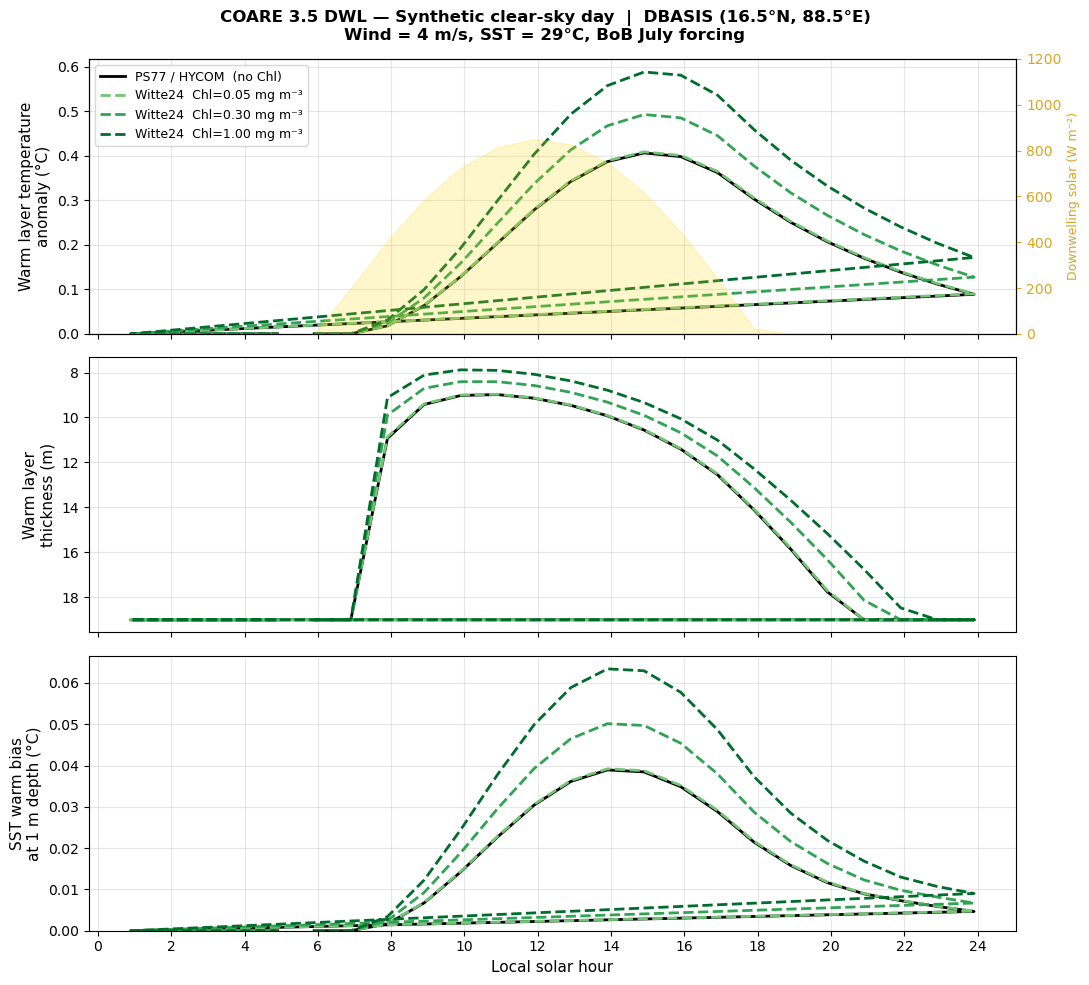

Saved figs/DWL_synthetic_day.png


In [24]:
# -------------------------------------------------------
# Figure 2: Synthetic single-day DWL test
# Idealized clear-sky forcing, typical BoB July conditions:
#   Solar: sinusoidal, peak 850 W/m² at local noon
#   IR:    400 W/m² (constant)
#   Wind:  4 m/s (calm, favors strong DWL)
#   hs:   −10 W/m² (small sensible, positive into ocean)
#   hl:   −90 W/m² (evaporation, positive into ocean)
#   SST:   29 °C
# Compare PS77/HYCOM vs. Witte24 at three Chl values
# -------------------------------------------------------
LON_REF = 88.5
times_syn = pd.date_range('2019-07-15 00:00', periods=24, freq='1h')

lsh = np.array([(t.hour + LON_REF / 15.0) % 24 for t in times_syn])

Solar_syn = np.maximum(0, 850 * np.sin(np.pi * (lsh - 6) / 12))
Solar_syn[lsh < 6]  = 0
Solar_syn[lsh > 18] = 0

IR_syn   = np.full(24, 400.0)
wspd_syn = np.full(24, 4.0)
hs_syn   = np.full(24, -10.0)
hl_syn   = np.full(24, -90.0)
Tsea_syn = np.full(24, 29.0)

runs = {
    'PS77 / HYCOM  (no Chl)':    ('PS77', 'k',       '-'),
    'Witte24  Chl=0.05 mg m⁻³':  (0.05,  '#74c476', '--'),
    'Witte24  Chl=0.30 mg m⁻³':  (0.30,  '#31a354', '--'),
    'Witte24  Chl=1.00 mg m⁻³':  (1.00,  '#006d2c', '--'),
}

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle(
    'COARE 3.5 DWL — Synthetic clear-sky day  |  DBASIS (16.5°N, 88.5°E)\n'
    'Wind = 4 m/s, SST = 29°C, BoB July forcing',
    fontsize=12, fontweight='bold'
)

x_lsh = [(t.hour + LON_REF/15.0) % 24 for t in times_syn]

for label, (chl, col, ls) in runs.items():
    res = dwl_run(times_syn, Solar_syn, IR_syn, wspd_syn, hs_syn, hl_syn,
                  Tsea_syn, LON_REF, Chl=chl)
    axes[0].plot(x_lsh, res['dt_wrm'], color=col, lw=2, ls=ls, label=label)
    axes[1].plot(x_lsh, res['tk_pwp'], color=col, lw=2, ls=ls)
    axes[2].plot(x_lsh, res['dsea'],   color=col, lw=2, ls=ls)

ax2 = axes[0].twinx()
ax2.fill_between(x_lsh, 0, Solar_syn, color='gold', alpha=0.2)
ax2.set_ylabel('Downwelling solar (W m⁻²)', fontsize=9, color='goldenrod')
ax2.tick_params(colors='goldenrod')
ax2.set_ylim(0, 1200)

axes[0].set_ylabel('Warm layer temperature\nanomaly (°C)', fontsize=11)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Warm layer\nthickness (m)', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel('SST warm bias\nat 1 m depth (°C)', fontsize=11)
axes[2].set_ylim(bottom=0)
axes[2].set_xlabel('Local solar hour', fontsize=11)
axes[2].set_xticks(range(0, 25, 2))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/DWL_synthetic_day.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/DWL_synthetic_day.png')

In [25]:
# -------------------------------------------------------
# Download ERA5 hourly forcing at DBASIS (16.5°N, 88.5°E)
# Variables needed to drive the COARE DWL model
# Period: 2019 (DBASIS campaign year)
#
# One request per month (12 total) — keeps field count well under CDS limits.
# Skip-if-exists so restartable.
# Output: era5_dbasis_forcing/ERA5_DBASIS_{yr}_{mm}.nc
# -------------------------------------------------------
import cdsapi

DBASIS_LAT = 16.5
DBASIS_LON = 88.5
dbox       = 0.25   # ± degrees around point

DWL_VARS = [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    'sea_surface_temperature',
    '2m_temperature',
    '2m_dewpoint_temperature',
    'mean_surface_downward_short_wave_radiation_flux',
    'mean_surface_downward_long_wave_radiation_flux',
    'mean_surface_sensible_heat_flux',
    'mean_surface_latent_heat_flux',
    'surface_pressure',
]

YEARS  = [2019]
OUTDIR = 'era5_dbasis_forcing'
os.makedirs(OUTDIR, exist_ok=True)

c = cdsapi.Client()

for year in YEARS:
    yr = str(year)
    for month in range(1, 13):
        mm  = f'{month:02d}'
        out = f'{OUTDIR}/ERA5_DBASIS_{yr}_{mm}.nc'
        if os.path.exists(out):
            print(f'{yr}-{mm}: exists, skipping')
            continue
        print(f'Downloading {yr}-{mm}...')
        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type':    'reanalysis',
                'variable':        DWL_VARS,
                'year':            yr,
                'month':           mm,
                'day':             [f'{d:02d}' for d in range(1, 32)],
                'time':            [f'{h:02d}:00' for h in range(24)],
                'area':            [DBASIS_LAT + dbox, DBASIS_LON - dbox,
                                    DBASIS_LAT - dbox, DBASIS_LON + dbox],
                'data_format':     'netcdf',
                'download_format': 'unarchived',
            },
            out,
        )
        print(f'  -> saved {out}')

print('All done.')

2019-01: exists, skipping
2019-02: exists, skipping
2019-03: exists, skipping
2019-04: exists, skipping
2019-05: exists, skipping
2019-06: exists, skipping
2019-07: exists, skipping
2019-08: exists, skipping
2019-09: exists, skipping
2019-10: exists, skipping
2019-11: exists, skipping
2019-12: exists, skipping
All done.


In [26]:
# -------------------------------------------------------
# Load ERA5 forcing and prepare DWL inputs
# CDS returns each monthly file as a ZIP with two NetCDF streams:
#   data_stream-oper_stepType-instant.nc  → u10, v10, sst, t2m, d2m, sp
#   data_stream-oper_stepType-avg.nc      → avg_sdswrf, avg_sdlwrf, avg_ishf, avg_slhtf
# Strategy: merge the two streams per month, then concat months.
# -------------------------------------------------------
import xarray as xr
import glob
import zipfile
import os

OUTDIR     = 'era5_dbasis_forcing'
DBASIS_LAT = 16.5
DBASIS_LON = 88.5

zip_files = sorted(glob.glob(f'{OUTDIR}/ERA5_DBASIS_????_??.nc'))
print(f'Found {len(zip_files)} monthly archives')

# Extract ZIPs (skip if already done)
extracted_dirs = []
for zpath in zip_files:
    tag   = os.path.basename(zpath).replace('.nc', '')
    exdir = os.path.join(OUTDIR, tag)
    if not os.path.isdir(exdir):
        print(f'Extracting {tag}...')
        os.makedirs(exdir, exist_ok=True)
        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(exdir)
    extracted_dirs.append(exdir)

# Merge the two streams per month, then concat across months
monthly = []
for exdir in extracted_dirs:
    files = sorted(glob.glob(f'{exdir}/*.nc'))
    parts = [xr.open_dataset(f, drop_variables=['number', 'expver'])
             for f in files]
    monthly.append(xr.merge(parts))

ds = xr.concat(monthly, dim='valid_time')
print('Variables:', list(ds.data_vars))
print('Time steps:', ds.sizes['valid_time'])

# Select nearest grid point to DBASIS
pt = ds.sel(latitude=DBASIS_LAT, longitude=DBASIS_LON, method='nearest').squeeze()

# Build forcing arrays
times = pd.DatetimeIndex(pt['valid_time'].values)
Solar = pt['avg_sdswrf'].values.ravel()   # W/m², mean downwelling SW
IR    = pt['avg_sdlwrf'].values.ravel()   # W/m², mean downwelling LW
u10   = pt['u10'].values.ravel()
v10   = pt['v10'].values.ravel()
wspd  = np.sqrt(u10**2 + v10**2)
hs    = pt['avg_ishf'].values.ravel()     # W/m², sensible (positive into ocean = negative here)
hl    = pt['avg_slhtf'].values.ravel()    # W/m², latent  (positive into ocean = negative here)
Tsea  = pt['sst'].values.ravel() - 273.15  # K → °C

print(f'\nTime range: {times[0]} – {times[-1]}  ({len(times)} hourly steps)')
print(f'Solar: {Solar.min():.1f} – {Solar.max():.1f} W/m²')
print(f'SST:   {Tsea.min():.1f} – {Tsea.max():.1f} °C')
print(f'Wind:  {wspd.min():.1f} – {wspd.max():.1f} m/s')
print(f'hs:    {hs.min():.1f} – {hs.max():.1f} W/m²  (ERA5 sign: + = ocean gains heat)')
print(f'hl:    {hl.min():.1f} – {hl.max():.1f} W/m²  (ERA5 sign: + = ocean gains heat)')

Found 12 monthly archives
Variables: ['avg_sdswrf', 'avg_sdlwrf', 'avg_ishf', 'avg_slhtf', 'u10', 'v10', 'sst', 't2m', 'd2m', 'sp']
Time steps: 8760

Time range: 2019-01-01 00:00:00 – 2019-12-31 23:00:00  (8760 hourly steps)
Solar: 0.0 – 1001.0 W/m²
SST:   25.1 – 30.7 °C
Wind:  0.0 – 17.6 m/s
hs:    -60.5 – 19.0 W/m²  (ERA5 sign: + = ocean gains heat)
hl:    -404.1 – -14.0 W/m²  (ERA5 sign: + = ocean gains heat)


Running PS77 (HYCOM)...
Running Witte24 Chl=0.10...
Running Witte24 Chl=0.50...
Done.


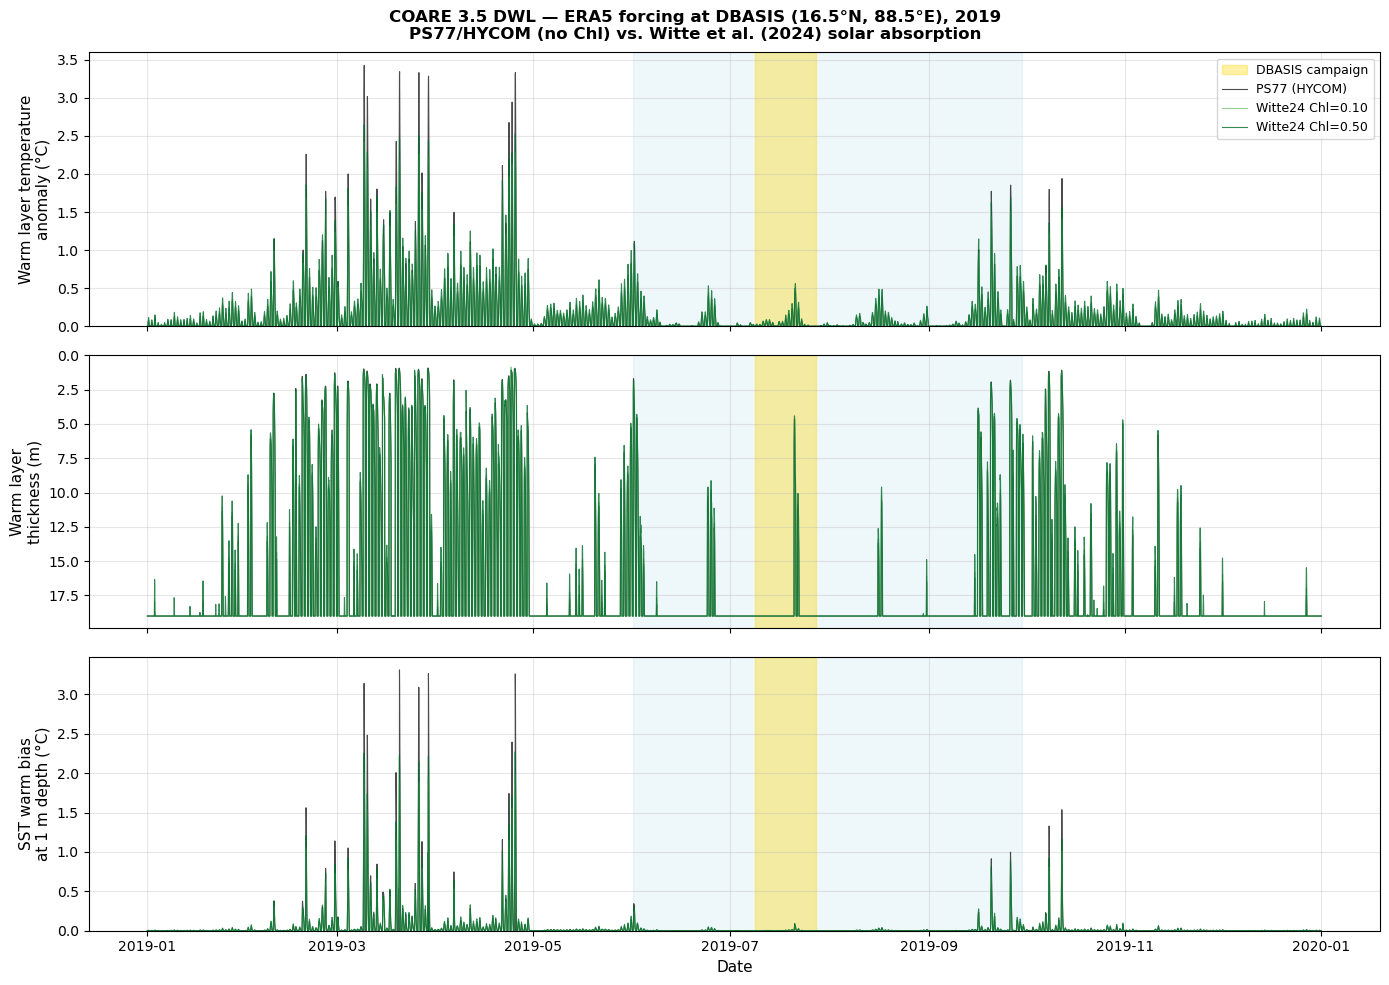

Saved figs/DWL_ERA5_2019.png


In [27]:
# -------------------------------------------------------
# Run DWL with ERA5 forcing — 2019
# Compare PS77/HYCOM (no Chl baseline) vs. Witte24 at two Chl values
#   Chl = 0.10 mg/m³ — typical background BoB
#   Chl = 0.50 mg/m³ — moderate bloom / post-monsoon
# -------------------------------------------------------
run_inputs = dict(
    time_utc = times,
    Solar    = Solar,
    IR       = IR,
    wspd     = wspd,
    hs       = hs,
    hl       = hl,
    Tsea     = Tsea,
    lon      = DBASIS_LON,
    ts_depth = 1.0,
)

print('Running PS77 (HYCOM)...')
res_ps77 = dwl_run(**run_inputs, Chl='PS77')
print('Running Witte24 Chl=0.10...')
res_w10  = dwl_run(**run_inputs, Chl=0.10)
print('Running Witte24 Chl=0.50...')
res_w50  = dwl_run(**run_inputs, Chl=0.50)
print('Done.')

# --- Plot 2019 ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    'COARE 3.5 DWL — ERA5 forcing at DBASIS (16.5°N, 88.5°E), 2019\n'
    'PS77/HYCOM (no Chl) vs. Witte et al. (2024) solar absorption',
    fontsize=12, fontweight='bold'
)

def shade_campaign(ax):
    ax.axvspan(pd.Timestamp('2019-07-09'), pd.Timestamp('2019-07-28'),
               color='gold', alpha=0.35, zorder=0, label='DBASIS campaign')
def shade_monsoon(ax, yr=2019):
    ax.axvspan(pd.Timestamp(f'{yr}-06-01'), pd.Timestamp(f'{yr}-09-30'),
               color='lightblue', alpha=0.2, zorder=0)

idx = res_ps77.index

for ax in axes:
    shade_monsoon(ax)
    shade_campaign(ax)

axes[0].plot(idx, res_ps77['dt_wrm'], 'k',       lw=0.8, alpha=0.7, label='PS77 (HYCOM)')
axes[0].plot(idx, res_w10['dt_wrm'],  '#74c476', lw=0.8, alpha=0.8, label='Witte24 Chl=0.10')
axes[0].plot(idx, res_w50['dt_wrm'],  '#006d2c', lw=0.8, alpha=0.8, label='Witte24 Chl=0.50')
axes[0].set_ylabel('Warm layer temperature\nanomaly (°C)', fontsize=11)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(idx, res_ps77['tk_pwp'], 'k',       lw=0.8, alpha=0.7)
axes[1].plot(idx, res_w10['tk_pwp'],  '#74c476', lw=0.8, alpha=0.8)
axes[1].plot(idx, res_w50['tk_pwp'],  '#006d2c', lw=0.8, alpha=0.8)
axes[1].set_ylabel('Warm layer\nthickness (m)', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

axes[2].plot(idx, res_ps77['dsea'], 'k',       lw=0.8, alpha=0.7)
axes[2].plot(idx, res_w10['dsea'],  '#74c476', lw=0.8, alpha=0.8)
axes[2].plot(idx, res_w50['dsea'],  '#006d2c', lw=0.8, alpha=0.8)
axes[2].set_ylabel('SST warm bias\nat 1 m depth (°C)', fontsize=11)
axes[2].set_ylim(bottom=0)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/DWL_ERA5_2019.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/DWL_ERA5_2019.png')

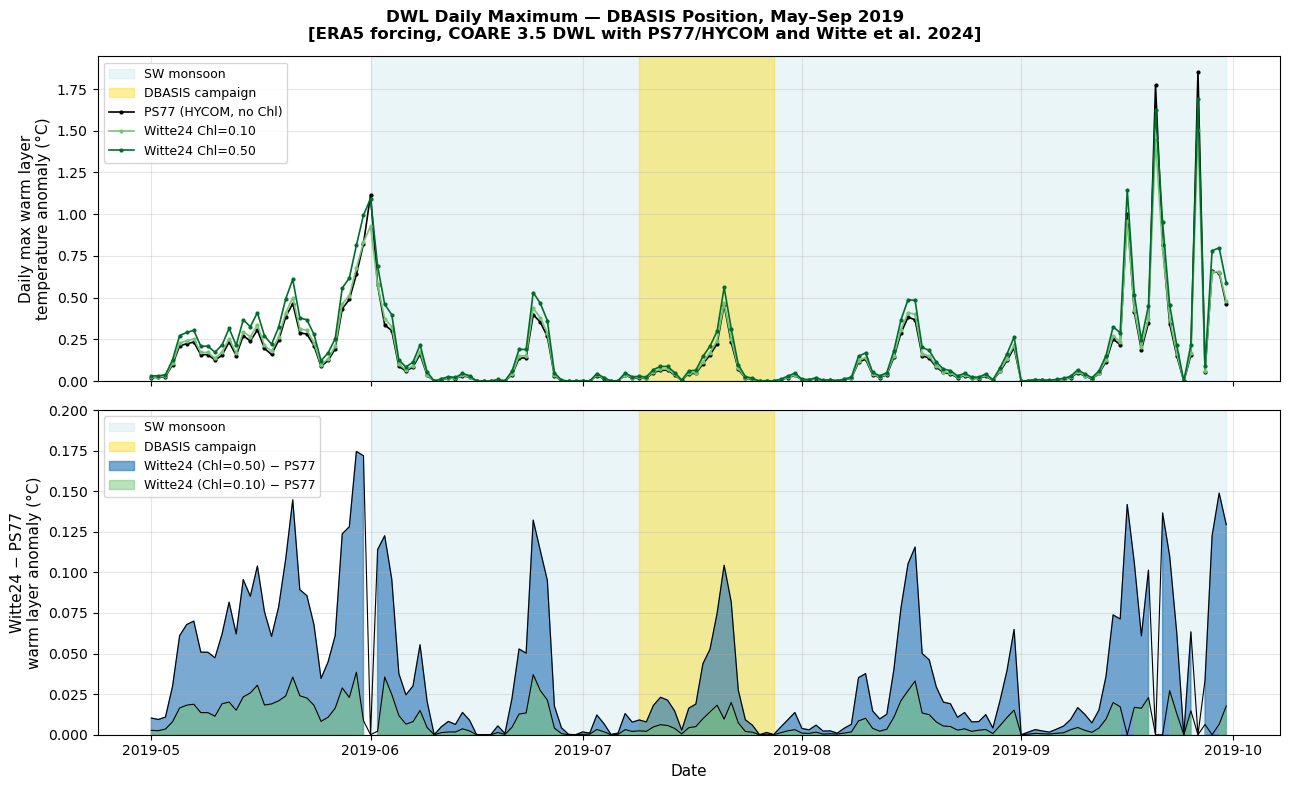

Saved figs/DWL_ERA5_2019_zoom.png


In [32]:
# -------------------------------------------------------
# Zoom: May–September 2019 (pre-monsoon → monsoon → post)
# Include DBASIS campaign window (9–28 July)
# Panel 1: daily max warm layer temperature anomaly
# Panel 2: Witte24 − PS77 difference (positive only)
# -------------------------------------------------------
mask_maysep = (idx >= '2019-05-01') & (idx < '2019-10-01')

def daily_max(series, mask):
    return series[mask].resample('1D').max()

dtw_ps77_d = daily_max(res_ps77['dt_wrm'], mask_maysep)
dtw_w10_d  = daily_max(res_w10['dt_wrm'],  mask_maysep)
dtw_w50_d  = daily_max(res_w50['dt_wrm'],  mask_maysep)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle(
    'DWL Daily Maximum — DBASIS Position, May–Sep 2019\n'
    '[ERA5 forcing, COARE 3.5 DWL with PS77/HYCOM and Witte et al. 2024]',
    fontsize=12, fontweight='bold'
)

for ax in axes:
    ax.axvspan(pd.Timestamp('2019-06-01'), pd.Timestamp('2019-09-30'),
               color='lightblue', alpha=0.25, label='SW monsoon')
    ax.axvspan(pd.Timestamp('2019-07-09'), pd.Timestamp('2019-07-28'),
               color='gold', alpha=0.4, label='DBASIS campaign')

axes[0].plot(dtw_ps77_d, 'k-o',  ms=2, lw=1.2, label='PS77 (HYCOM, no Chl)')
axes[0].plot(dtw_w10_d, color='#74c476', marker='o', ms=2, lw=1.2, label='Witte24 Chl=0.10')
axes[0].plot(dtw_w50_d, color='#006d2c', marker='o', ms=2, lw=1.2, label='Witte24 Chl=0.50')
axes[0].set_ylabel('Daily max warm layer\ntemperature anomaly (°C)', fontsize=11)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

diff_10 = dtw_w10_d - dtw_ps77_d
diff_50 = dtw_w50_d - dtw_ps77_d
axes[1].fill_between(diff_50.index, 0, diff_50.values,
                     where=(diff_50.values >= 0), color='#2171b5', alpha=0.6, label='Witte24 (Chl=0.50) − PS77')
axes[1].plot(diff_50.index, diff_50.values.clip(min=0), color='k', lw=0.8)
axes[1].fill_between(diff_10.index, 0, diff_10.values,
                     where=(diff_10.values >= 0), color='#74c476', alpha=0.5, label='Witte24 (Chl=0.10) − PS77')
axes[1].plot(diff_10.index, diff_10.values.clip(min=0), color='k', lw=0.8)
axes[1].set_ylim(0, 0.2)
axes[1].set_ylabel('Witte24 − PS77\nwarm layer anomaly (°C)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/DWL_ERA5_2019_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/DWL_ERA5_2019_zoom.png')